In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize data
x_train = x_train.reshape(-1, 784).astype('float32') / 255.0
x_test = x_test.reshape(-1, 784).astype('float32') / 255.0

# Convert labels to one-hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [3]:
# Define model architecture parameters
input_num_units = 784
hidden1_num_units = 500
hidden2_num_units = 500
hidden3_num_units = 500
hidden4_num_units = 500
hidden5_num_units = 500
output_num_units = 10
epochs = 10
batch_size = 128

In [4]:
# 1. Simple Neural Network
model_simple = Sequential([
    Dense(hidden1_num_units, input_dim=input_num_units, activation='relu'),
    Dense(hidden2_num_units, activation='relu'),
    Dense(hidden3_num_units, activation='relu'),
    Dense(hidden4_num_units, activation='relu'),
    Dense(hidden5_num_units, activation='relu'),
    Dense(output_num_units, activation='softmax'),
])

model_simple.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_simple = model_simple.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test))

C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - accuracy: 0.8623 - loss: 0.4331 - val_accuracy: 0.9621 - val_loss: 0.1217
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9703 - loss: 0.0968 - val_accuracy: 0.9736 - val_loss: 0.0867
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9800 - loss: 0.0622 - val_accuracy: 0.9690 - val_loss: 0.1095
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9833 - loss: 0.0537 - val_accuracy: 0.9768 - val_loss: 0.0927
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9879 - loss: 0.0412 - val_accuracy: 0.9781 - val_loss: 0.0834
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.9891 - loss: 0.0344 - val_accuracy: 0.9791 - val_loss: 0.0736
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.9918 - loss: 0.0281 - val_accuracy: 0.9737 - val_loss: 0.0978
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.9913 - loss: 0.0303 - 

In [5]:
# 2. Neural Network with L2 Regularization
model_l2 = Sequential([
    Dense(hidden1_num_units, input_dim=input_num_units, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
    Dense(hidden2_num_units, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
    Dense(hidden3_num_units, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
    Dense(hidden4_num_units, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
    Dense(hidden5_num_units, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
    Dense(output_num_units, activation='softmax'),
])

model_l2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_l2 = model_l2.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.8698 - loss: 0.6308 - val_accuracy: 0.9659 - val_loss: 0.2785
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9703 - loss: 0.2533 - val_accuracy: 0.9651 - val_loss: 0.2517
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.9778 - loss: 0.2045 - val_accuracy: 0.9764 - val_loss: 0.2045
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9840 - loss: 0.1677 - val_accuracy: 0.9759 - val_loss: 0.1903
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9849 - loss: 0.1479 - val_accuracy: 0.9666 - val_loss: 0.2099
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.9839 - loss: 0.1418 - val_accuracy: 0.9722 - val_loss: 0.1848
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9889 - loss: 0.1217 - val_accuracy: 0.9787 - val_loss: 0.1571
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9887 - loss: 0.1177 - 

In [6]:
# 3. Neural Network with L1 Regularization
model_l1 = Sequential([
    Dense(hidden1_num_units, input_dim=input_num_units, activation='relu', kernel_regularizer=regularizers.l1(0.0001)),
    Dense(hidden2_num_units, activation='relu', kernel_regularizer=regularizers.l1(0.0001)),
    Dense(hidden3_num_units, activation='relu', kernel_regularizer=regularizers.l1(0.0001)),
    Dense(hidden4_num_units, activation='relu', kernel_regularizer=regularizers.l1(0.0001)),
    Dense(hidden5_num_units, activation='relu', kernel_regularizer=regularizers.l1(0.0001)),
    Dense(output_num_units, activation='softmax'),
])

model_l1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_l1 = model_l1.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 42ms/step - accuracy: 0.8642 - loss: 3.3044 - val_accuracy: 0.9634 - val_loss: 1.1654
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.9609 - loss: 0.9837 - val_accuracy: 0.9583 - val_loss: 0.6259
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.9669 - loss: 0.5445 - val_accuracy: 0.9735 - val_loss: 0.3947
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.9733 - loss: 0.3738 - val_accuracy: 0.9693 - val_loss: 0.3439
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.9746 - loss: 0.3134 - val_accuracy: 0.9725 - val_loss: 0.2914
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.9794 - loss: 0.2649 - val_accuracy: 0.9745 - val_loss: 0.2655
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.9803 - loss: 0.2377 - val_accuracy: 0.9781 - val_loss: 0.2430
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.9827 - loss: 0.2207 - 

In [7]:
# 4. Neural Network with Dropout
model_dropout = Sequential([
    Dense(hidden1_num_units, input_dim=input_num_units, activation='relu'),
    Dropout(0.25),
    Dense(hidden2_num_units, activation='relu'),
    Dropout(0.25),
    Dense(hidden3_num_units, activation='relu'),
    Dropout(0.25),
    Dense(hidden4_num_units, activation='relu'),
    Dropout(0.25),
    Dense(hidden5_num_units, activation='relu'),
    Dropout(0.25),
    Dense(output_num_units, activation='softmax'),
])

model_dropout.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_dropout = model_dropout.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 38ms/step - accuracy: 0.8040 - loss: 0.5945 - val_accuracy: 0.9570 - val_loss: 0.1366
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.9551 - loss: 0.1531 - val_accuracy: 0.9700 - val_loss: 0.1065
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.9671 - loss: 0.1128 - val_accuracy: 0.9725 - val_loss: 0.0993
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.9742 - loss: 0.0915 - val_accuracy: 0.9742 - val_loss: 0.0898
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.9773 - loss: 0.0760 - val_accuracy: 0.9789 - val_loss: 0.0790
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.9791 - loss: 0.0691 - val_accuracy: 0.9794 - val_loss: 0.0769
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.9819 - loss: 0.0597 - val_accuracy: 0.9801 - val_loss: 0.0715
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.9842 - loss: 0.0553 - 

In [8]:
# 5. Neural Network with Early Stopping
model_early_stopping = Sequential([
    Dense(hidden1_num_units, input_dim=input_num_units, activation='relu'),
    Dense(hidden2_num_units, activation='relu'),
    Dense(hidden3_num_units, activation='relu'),
    Dense(hidden4_num_units, activation='relu'),
    Dense(hidden5_num_units, activation='relu'),
    Dense(output_num_units, activation='softmax'),
])

model_early_stopping.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_accuracy', patience=2)
history_early_stopping = model_early_stopping.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test), callbacks=[early_stopping])

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - accuracy: 0.8631 - loss: 0.4282 - val_accuracy: 0.9630 - val_loss: 0.1155
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9725 - loss: 0.0915 - val_accuracy: 0.9749 - val_loss: 0.0900
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.9806 - loss: 0.0616 - val_accuracy: 0.9750 - val_loss: 0.0911
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.9852 - loss: 0.0499 - val_accuracy: 0.9761 - val_loss: 0.0848
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9881 - loss: 0.0403 - val_accuracy: 0.9790 - val_loss: 0.0792
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9887 - loss: 0.0382 - val_accuracy: 0.9788 - val_loss: 0.0945
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9898 - loss: 0.0342 - val_accuracy: 0.9795 - val_loss: 0.0783
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9910 - loss: 0.0290 - 

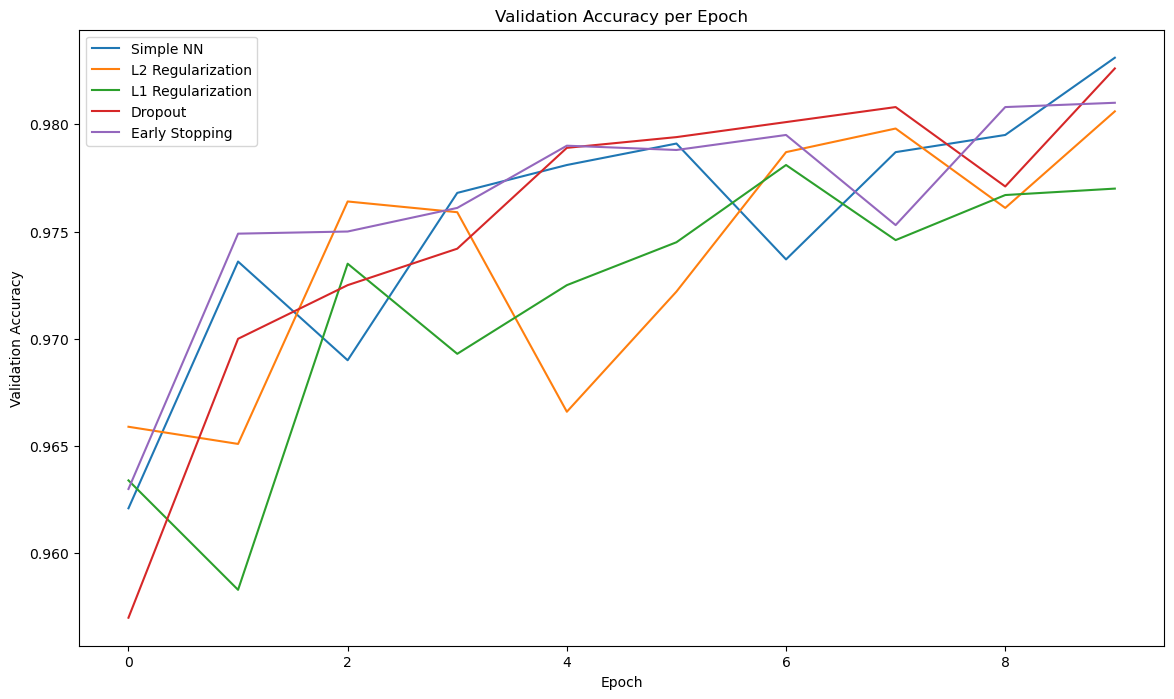

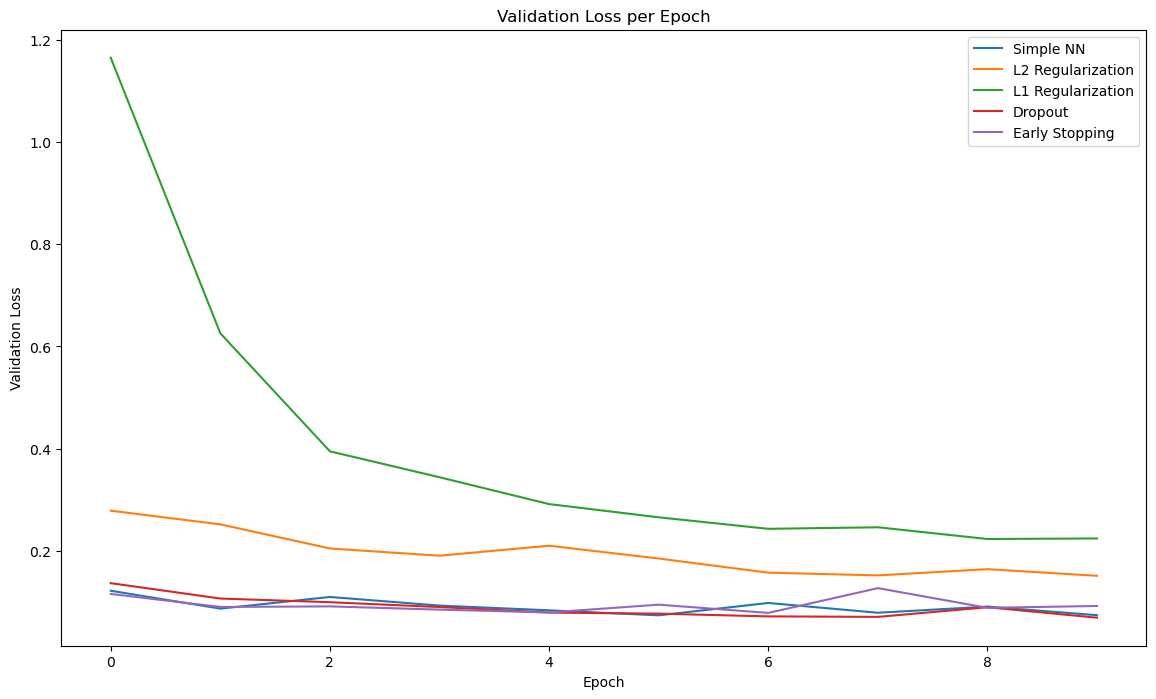

In [9]:
# Display results
results = {
    "Simple NN": history_simple.history,
    "L2 Regularization": history_l2.history,
    "L1 Regularization": history_l1.history,
    "Dropout": history_dropout.history,
    "Early Stopping": history_early_stopping.history
}

# Plot accuracy for each model
plt.figure(figsize=(14, 8))
for key in results.keys():
    plt.plot(results[key]['val_accuracy'], label=key)
plt.title('Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

# Plot loss for each model
plt.figure(figsize=(14, 8))
for key in results.keys():
    plt.plot(results[key]['val_loss'], label=key)
plt.title('Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

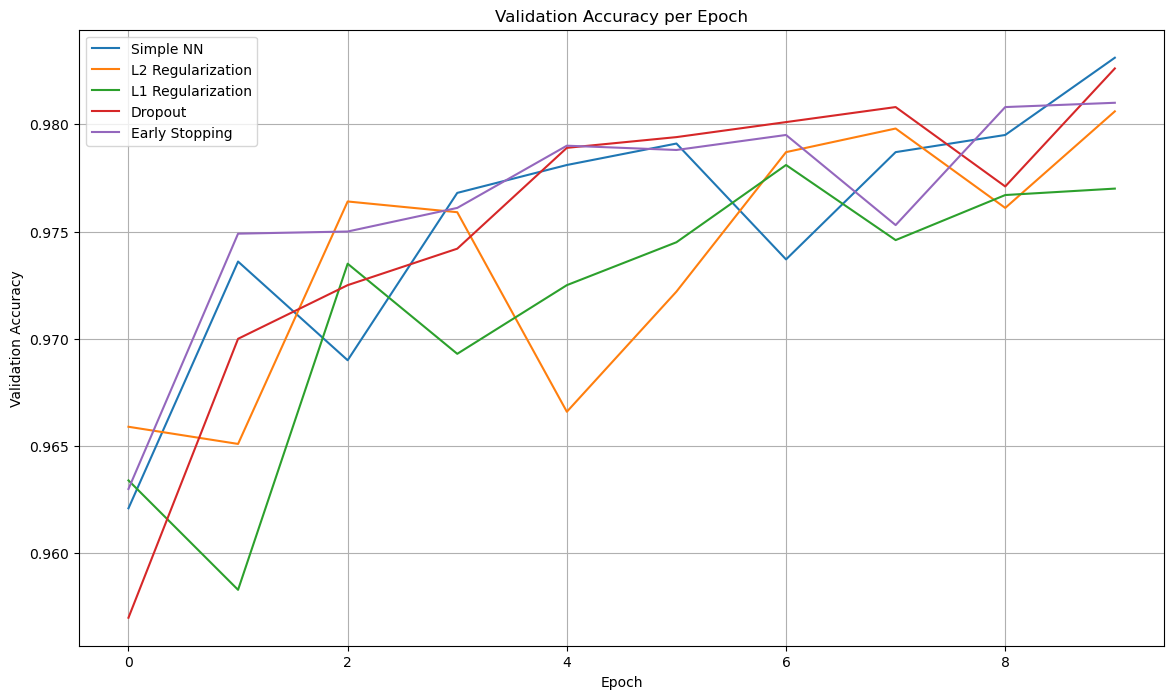

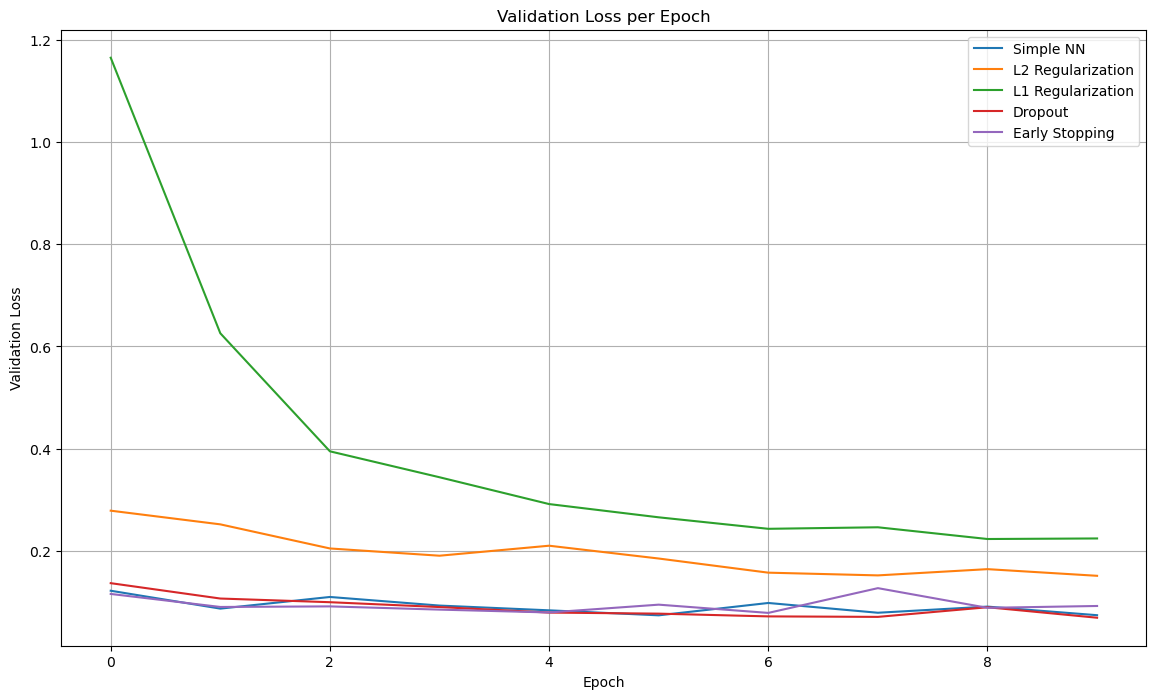

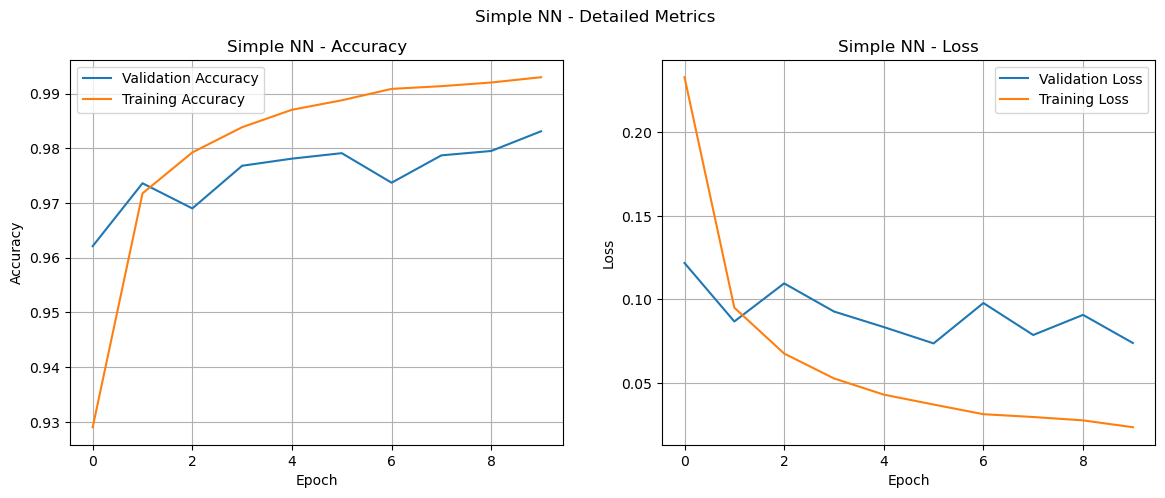

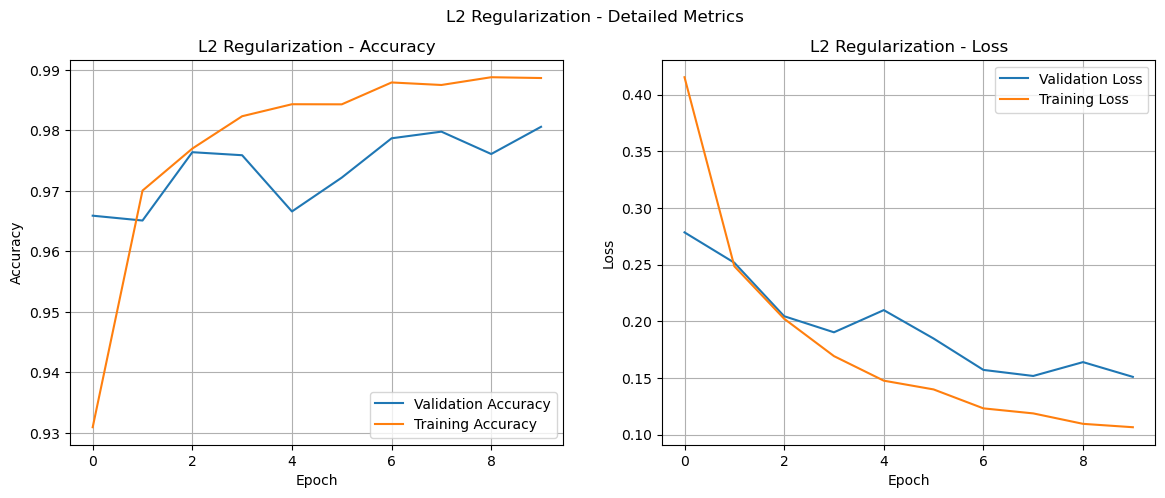

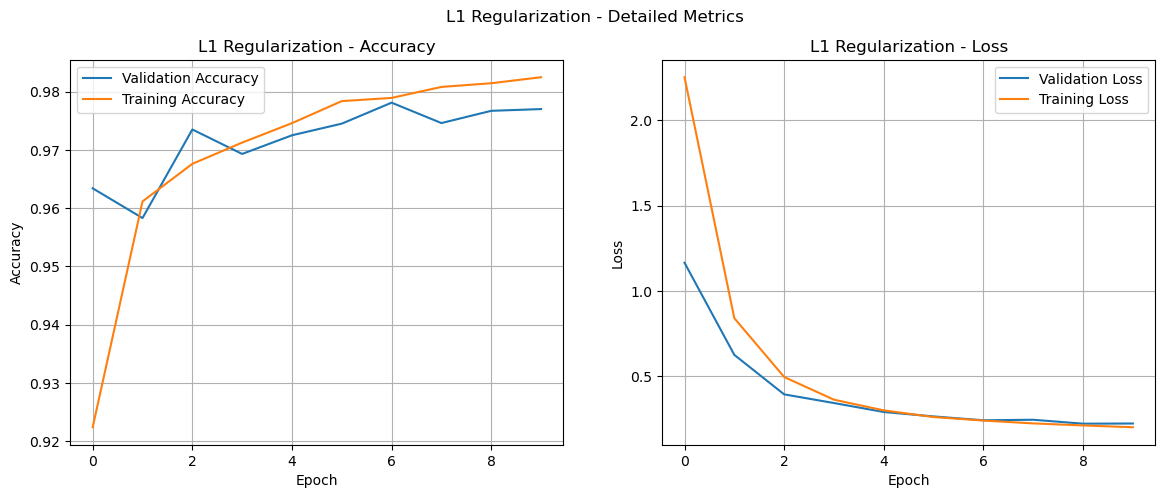

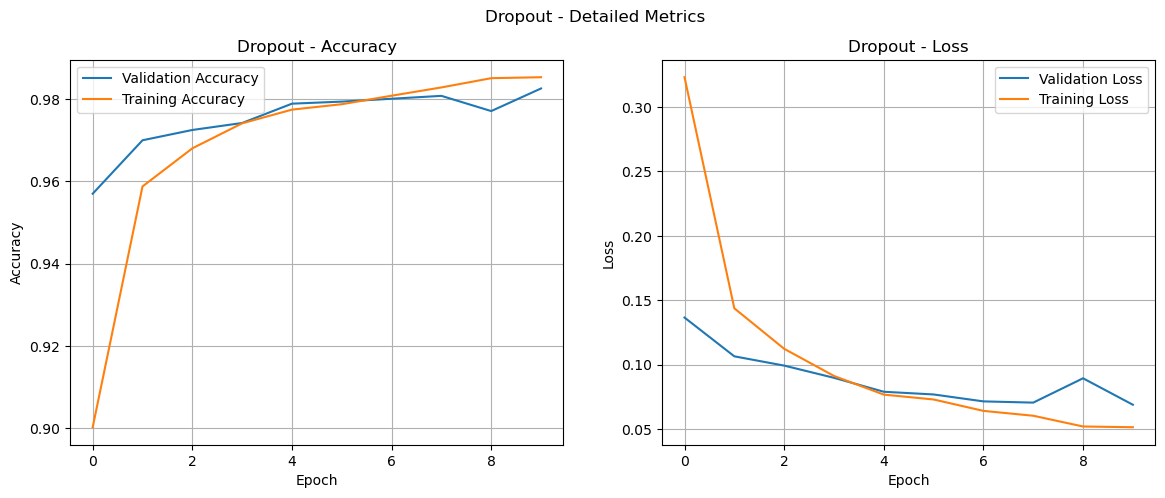

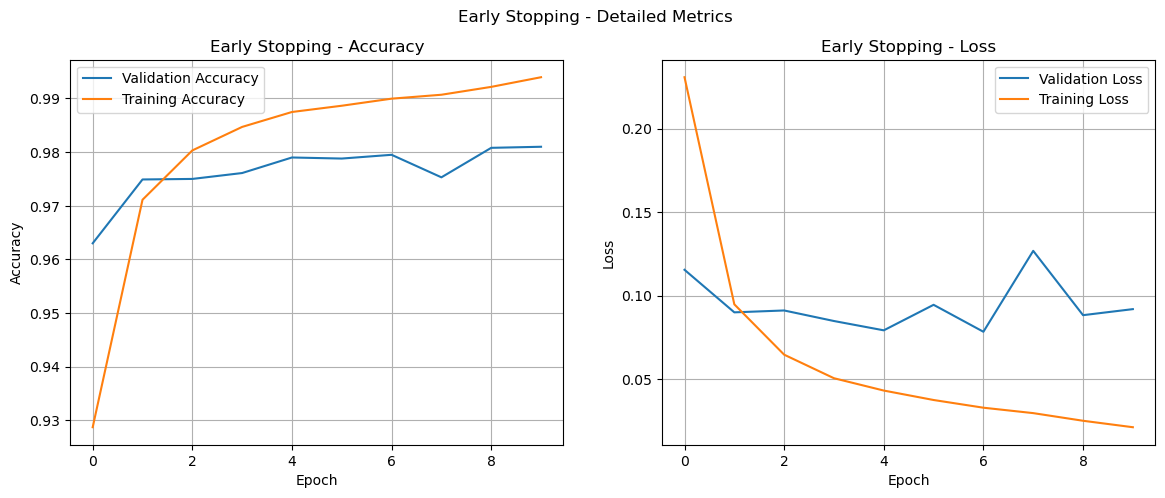

In [20]:
# Plot accuracy for each model
plt.figure(figsize=(14, 8))
for key in results.keys():
    plt.plot(results[key]['val_accuracy'], label=key)
plt.title('Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss for each model
plt.figure(figsize=(14, 8))
for key in results.keys():
    plt.plot(results[key]['val_loss'], label=key)
plt.title('Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot detailed accuracy and loss for each model
for key in results.keys():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(results[key]['val_accuracy'], label='Validation Accuracy')
    ax1.plot(results[key]['accuracy'], label='Training Accuracy')
    ax1.set_title(f'{key} - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(results[key]['val_loss'], label='Validation Loss')
    ax2.plot(results[key]['loss'], label='Training Loss')
    ax2.set_title(f'{key} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.suptitle(f'{key} - Detailed Metrics')
    plt.show()

In [26]:
model_elastic = Sequential([
    Dense(hidden1_num_units, input_dim=input_num_units, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.0001)),
    Dense(hidden2_num_units, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.0001)),
    Dense(hidden3_num_units, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.0001)),
    Dense(hidden4_num_units, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.0001)),
    Dense(hidden5_num_units, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.0001)),
    Dense(output_num_units, activation='softmax'),
])

model_elastic.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_elastic = model_elastic.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.8526 - loss: 3.4753 - val_accuracy: 0.9625 - val_loss: 1.1783
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.9564 - loss: 0.9981 - val_accuracy: 0.9627 - val_loss: 0.6059
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9678 - loss: 0.5261 - val_accuracy: 0.9689 - val_loss: 0.3990
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9723 - loss: 0.3668 - val_accuracy: 0.9703 - val_loss: 0.3317
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.9741 - loss: 0.3066 - val_accuracy: 0.9732 - val_loss: 0.2881
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.9784 - loss: 0.2635 - val_accuracy: 0.9719 - val_loss: 0.2713
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - accuracy: 0.9790 - loss: 0.2433 - val_accuracy: 0.9763 - val_loss: 0.2412
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.9812 - loss: 0.2249 - 

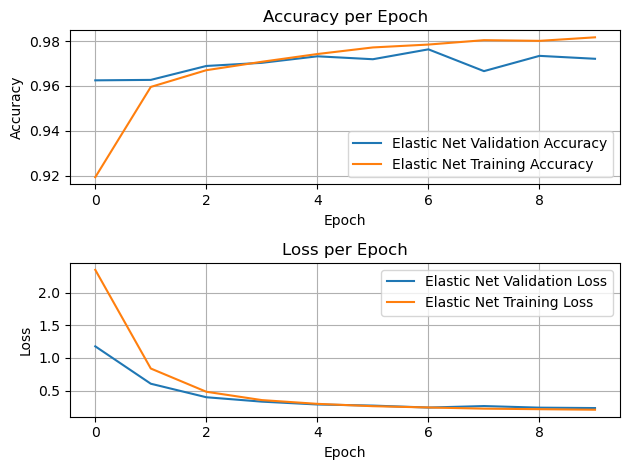

In [27]:
plt.subplot(2, 1, 1)
plt.plot(history_elastic.history['val_accuracy'], label='Elastic Net Validation Accuracy')
plt.plot(history_elastic.history['accuracy'], label='Elastic Net Training Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.subplot(2, 1, 2)
plt.plot(history_elastic.history['val_loss'], label='Elastic Net Validation Loss')
plt.plot(history_elastic.history['loss'], label='Elastic Net Training Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
def inverted_dropout(x, dropout_rate=0.5):
    retain_prob = 1 - dropout_rate
    x = K.dropout(x, level=dropout_rate)
    x /= retain_prob
    return x

model_inverted_dropout = Sequential([
    Dense(hidden1_num_units, input_dim=input_num_units, activation='relu'),
    Lambda(inverted_dropout),
    Dense(hidden2_num_units, activation='relu'),
    Lambda(inverted_dropout),
    Dense(hidden3_num_units, activation='relu'),
    Lambda(inverted_dropout),
    Dense(hidden4_num_units, activation='relu'),
    Lambda(inverted_dropout),
    Dense(hidden5_num_units, activation='relu'),
    Lambda(inverted_dropout),
    Dense(output_num_units, activation='softmax'),
])

model_inverted_dropout.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_inverted_dropout = model_inverted_dropout.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test))

# 5. نمایش نتایج
results = {
    "Standard Dropout": history_standard_dropout.history,
    "Inverted Dropout": history_inverted_dropout.history
}

# نمایش دقت و از دست دادن برای هر مدل
plt.figure(figsize=(14, 8))

# دقت اعتبارسنجی
plt.subplot(2, 1, 1)
plt.plot(results["Standard Dropout"]['val_accuracy'], label='Standard Dropout Validation Accuracy')
plt.plot(results["Standard Dropout"]['accuracy'], label='Standard Dropout Training Accuracy')
plt.plot(results["Inverted Dropout"]['val_accuracy'], label='Inverted Dropout Validation Accuracy')
plt.plot(results["Inverted Dropout"]['accuracy'], label='Inverted Dropout Training Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# از دست دادن اعتبارسنجی
plt.subplot(2, 1, 2)
plt.plot(results["Standard Dropout"]['val_loss'], label='Standard Dropout Validation Loss')
plt.plot(results["Standard Dropout"]['loss'], label='Standard Dropout Training Loss')
plt.plot(results["Inverted Dropout"]['val_loss'], label='Inverted Dropout Validation Loss')
plt.plot(results["Inverted Dropout"]['loss'], label='Inverted Dropout Training Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()